In [1]:
library(dplyr)
library(readr)
library(tidyr)
library(ggplot2)
library(ggforce)
library(ggpubr)
library(rstatix)
library(ggrepel)

set.seed(123)

# -----------------------------
# paths and settings
# -----------------------------
#setwd("/tgen_labs/barthel/projects/Jenkins_Mayo/glass_TCGA/CNVs_by_subtypes")
setwd("/scratch/mjehangir/new_paired_data/")

arm_file <- "/home/mjehangir/softwares/Arm-Level-Aneuploidy/data/genomic_arm_coordinates_hg19.txt"

pal <- c(
  "Astrocytoma"       = "#009E73",
  "GBM"               = "#377EB8",
  "Oligodendroglioma" = "#F0E442"
)

aneuploidy_threshold <- 0.80
segmean_threshold    <- 0.20
prefer_cna_status    <- FALSE

format_p <- function(p) {
  ifelse(p < 0.001, formatC(p, format = "e", digits = 1), sprintf("%.4f", p))
}


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter




In [2]:
# -----------------------------
# load arm coordinates
# -----------------------------
arm_lengths <- read_tsv(arm_file, col_types = cols(), comment = "#") %>%
  rename(arm_start = start, arm_end = end) %>%
  mutate(
    chrom = paste0("chr", sub("^chr", "", as.character(chrom))),
    arm_length = arm_end - arm_start
  ) %>%
  select(chrom, side, arm, arm_start, arm_end, arm_length)

head(arm_lengths)

chrom,side,arm,arm_start,arm_end,arm_length
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
chr1,p,1p,0.00e+00,125000000,125000000
chr1,q,1q,1.25e+08,249250621,124250621
chr10,p,10p,0.00e+00,40200000,40200000
chr10,q,10q,4.02e+07,135534747,95334747
chr11,p,11p,0.00e+00,53700000,53700000
chr11,q,11q,5.37e+07,135006516,81306516


In [3]:
# -----------------------------
# load CNV segment files
# -----------------------------
files <- list.files(pattern = "_(primary|recurrence)\\.seg$", full.names = TRUE)

cnv_all <- bind_rows(lapply(files, function(file) {
  read_tsv(file, col_types = cols()) %>%
    mutate(
      tumor_type = case_when(
        grepl("astro", basename(file), ignore.case = TRUE) ~ "Astrocytoma",
        grepl("oligo", basename(file), ignore.case = TRUE) ~ "Oligodendroglioma",
        grepl("gbm", basename(file), ignore.case = TRUE)   ~ "GBM",
        TRUE ~ "Other"
      ),
      stage = case_when(
        grepl("primary", basename(file), ignore.case = TRUE)    ~ "Primary",
        grepl("recurrence", basename(file), ignore.case = TRUE) ~ "Recurrence",
        TRUE ~ NA_character_
      ),
      sample = ID,
      chrom = paste0("chr", sub("^chr", "", as.character(chrom))),
      segment_length = loc.end - loc.start
    )
}))

head(cnv_all)

ID,chrom,loc.start,loc.end,num.mark,seg.mean,tumor_type,stage,sample,segment_length
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>
GLSS-SF-0024-TP,chr1,860322,249213562,16326,-0.012005,Astrocytoma,Primary,GLSS-SF-0024-TP,248353240
GLSS-SF-0024-TP,chr2,40609,242816426,12095,-0.016352,Astrocytoma,Primary,GLSS-SF-0024-TP,242775817
GLSS-SF-0024-TP,chr3,366670,197766538,9993,-0.002309,Astrocytoma,Primary,GLSS-SF-0024-TP,197399868
GLSS-SF-0024-TP,chr4,84622,190863195,6516,-0.043278,Astrocytoma,Primary,GLSS-SF-0024-TP,190778573
GLSS-SF-0024-TP,chr5,139423,180688814,7404,-0.012733,Astrocytoma,Primary,GLSS-SF-0024-TP,180549391
GLSS-SF-0024-TP,chr6,303628,32165800,1139,-0.014521,Astrocytoma,Primary,GLSS-SF-0024-TP,31862172


In [4]:
# -----------------------------
# overlap with chromosome arms
# -----------------------------
cnv_with_arms <- cnv_all %>%
  left_join(arm_lengths, by = "chrom") %>%
  filter(loc.start < arm_end, loc.end > arm_start) %>%
  mutate(
    overlap_start = pmax(loc.start, arm_start),
    overlap_end   = pmin(loc.end, arm_end),
    overlap_len   = pmax(0, overlap_end - overlap_start),
    cna_status    = case_when(
      seg.mean > 0 ~ 1,
      seg.mean < 0 ~ -1,
      TRUE ~ 0
    )
  )

head(cnv_with_arms)

Warning message in left_join(., arm_lengths, by = "chrom"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 37 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


ID,chrom,loc.start,loc.end,num.mark,seg.mean,tumor_type,stage,sample,segment_length,side,arm,arm_start,arm_end,arm_length,overlap_start,overlap_end,overlap_len,cna_status
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
GLSS-SF-0024-TP,chr1,860322,249213562,16326,-0.012005,Astrocytoma,Primary,GLSS-SF-0024-TP,248353240,p,1p,0.00e+00,125000000,125000000,860322,125000000,124139678,-1
GLSS-SF-0024-TP,chr1,860322,249213562,16326,-0.012005,Astrocytoma,Primary,GLSS-SF-0024-TP,248353240,q,1q,1.25e+08,249250621,124250621,125000000,249213562,124213562,-1
GLSS-SF-0024-TP,chr2,40609,242816426,12095,-0.016352,Astrocytoma,Primary,GLSS-SF-0024-TP,242775817,p,2p,0.00e+00,93300000,93300000,40609,93300000,93259391,-1
GLSS-SF-0024-TP,chr2,40609,242816426,12095,-0.016352,Astrocytoma,Primary,GLSS-SF-0024-TP,242775817,q,2q,9.33e+07,243199373,149899373,93300000,242816426,149516426,-1
GLSS-SF-0024-TP,chr3,366670,197766538,9993,-0.002309,Astrocytoma,Primary,GLSS-SF-0024-TP,197399868,p,3p,0.00e+00,91000000,91000000,366670,91000000,90633330,-1
GLSS-SF-0024-TP,chr3,366670,197766538,9993,-0.002309,Astrocytoma,Primary,GLSS-SF-0024-TP,197399868,q,3q,9.10e+07,198022430,107022430,91000000,197766538,106766538,-1


In [5]:
# -----------------------------
# sample summary table
# -----------------------------
sample_table <- cnv_with_arms %>%
  filter(cna_status != 0) %>%
  distinct(sample, tumor_type, stage) %>%
  count(tumor_type, stage, name = "unique_samples") %>%
  pivot_wider(names_from = stage, values_from = unique_samples, values_fill = 0) %>%
  mutate(Total = Primary + Recurrence) %>%
  bind_rows(
    summarise(
      .,
      tumor_type = "Total",
      Primary = sum(Primary),
      Recurrence = sum(Recurrence),
      Total = sum(Total)
    )
  )

print(sample_table)

# A tibble: 4 × 4
  tumor_type        Primary Recurrence Total
  <chr>               <int>      <int> <int>
1 Astrocytoma            74         74   148
2 GBM                   173        171   344
3 Oligodendroglioma      25         25    50
4 Total                 272        270   542


In [6]:
# -----------------------------
# helper function to compute scores
# -----------------------------
compute_sample_scores <- function(df, by_stage = FALSE) {
  df <- df %>%
    mutate(
      arm_length  = as.numeric(arm_length),
      overlap_len = as.numeric(overlap_len),
      seg.mean    = as.numeric(seg.mean),
      cna_status  = suppressWarnings(as.numeric(cna_status)),
      Patient_ID  = substr(as.character(ID), 1, 12)
    )

  use_cna_status <- prefer_cna_status && any(!is.na(df$cna_status))

  df <- df %>%
    mutate(
      is_altered = if (use_cna_status) cna_status != 0 else abs(seg.mean) >= segmean_threshold
    )

  if (by_stage) {
    df <- df %>%
      mutate(
        stage = case_when(
          grepl("prim", tolower(stage)) ~ "Primary",
          grepl("rec",  tolower(stage)) ~ "Recurrence",
          TRUE ~ NA_character_
        )
      ) %>%
      filter(stage %in% c("Primary", "Recurrence"))
  }

  arm_groups    <- c("ID", "Patient_ID", "tumor_type", if (by_stage) "stage", "arm")
  sample_groups <- c("ID", "Patient_ID", "tumor_type", if (by_stage) "stage")

  arm_summary <- df %>%
    group_by(across(all_of(arm_groups))) %>%
    summarise(
      arm_length = max(arm_length, na.rm = TRUE),
      altered_bp = sum(overlap_len[is_altered], na.rm = TRUE),
      .groups = "drop"
    ) %>%
    mutate(
      altered_bp   = pmin(altered_bp, arm_length),
      frac_altered = ifelse(arm_length > 0, altered_bp / arm_length, NA_real_),
      is_aneuploid = frac_altered >= aneuploidy_threshold
    )

  arm_summary %>%
    group_by(across(all_of(sample_groups))) %>%
    summarise(
      n_aneuploid_arms     = sum(is_aneuploid, na.rm = TRUE),
      segmental_bp         = sum(altered_bp[!is_aneuploid], na.rm = TRUE),
      total_arm_bp         = sum(arm_length, na.rm = TRUE),
      segmental_cnv_burden = segmental_bp / total_arm_bp,
      .groups = "drop"
    ) %>%
    arrange(across(all_of(sample_groups)))
}

In [7]:
sample_scores_primary <- cnv_with_arms %>%
  filter(stage == "Primary") %>%
  compute_sample_scores(by_stage = FALSE)

sample_scores_stage <- compute_sample_scores(cnv_with_arms, by_stage = TRUE)

head(sample_scores_primary)
head(sample_scores_stage)

ID,Patient_ID,tumor_type,n_aneuploid_arms,segmental_bp,total_arm_bp,segmental_cnv_burden
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
GLSS-19-0266-TP,GLSS-19-0266,GBM,11,52197672,2811833286,0.01856357
GLSS-19-0267-TP,GLSS-19-0267,GBM,7,139200059,2811833286,0.04950509
GLSS-19-0268-TP,GLSS-19-0268,GBM,17,109428161,2811833286,0.03891702
GLSS-19-0269-TP,GLSS-19-0269,GBM,5,30339416,2811833286,0.01078991
GLSS-19-0270-TP,GLSS-19-0270,GBM,5,108359573,2811833286,0.03853698
GLSS-19-0271-TP,GLSS-19-0271,GBM,9,60934298,2811833286,0.02167067


ID,Patient_ID,tumor_type,stage,n_aneuploid_arms,segmental_bp,total_arm_bp,segmental_cnv_burden
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
GLSS-19-0266-R1,GLSS-19-0266,GBM,Recurrence,6,295236117,2811833286,1.049977e-01
GLSS-19-0266-TP,GLSS-19-0266,GBM,Primary,11,52197672,2811833286,1.856357e-02
GLSS-19-0267-R1,GLSS-19-0267,GBM,Recurrence,1,205104258,2811833286,7.294325e-02
GLSS-19-0267-TP,GLSS-19-0267,GBM,Primary,7,139200059,2811833286,4.950509e-02
GLSS-19-0268-R1,GLSS-19-0268,GBM,Recurrence,0,6399,2811833286,2.275739e-06
GLSS-19-0268-TP,GLSS-19-0268,GBM,Primary,17,109428161,2811833286,3.891702e-02


In [8]:
# -----------------------------
# plotting function: for tumor type comparisons of aneuploidy
# -----------------------------
plot_by_tumor_type <- function(data, y, ylab, title) {
  dat <- data %>%
    filter(!is.na(tumor_type), !is.na(.data[[y]]), tumor_type %in% names(pal)) %>%
    mutate(tumor_type = factor(tumor_type, levels = names(pal)))

  counts <- dat %>% count(tumor_type, name = "n")

  y_max <- max(dat[[y]], na.rm = TRUE)
  step  <- max(y_max * 0.12, ifelse(y_max > 1, 1, 0.02))

  stats <- compare_means(
    formula = as.formula(paste(y, "~ tumor_type")),
    data = dat,
    #method = "t.test", #independent t test (unpaired)
          method = "wilcox.test", #independent t test (unpaired)

    #paired = FALSE, #this is for comparing different tumor types for the primary samples only
    p.adjust.method = "BH"
  ) %>%
    mutate(
      y.position = y_max + seq_len(n()) * step,
      p.label = format_p(p.adj)
    )

  x_labels <- setNames(
    paste0(as.character(counts$tumor_type), "\n(n=", counts$n, ")"),
    as.character(counts$tumor_type)
  )

  ggplot(dat, aes(x = tumor_type, y = .data[[y]], fill = tumor_type, color = tumor_type)) +
    geom_violin(alpha = 0.3, trim = FALSE, width = 0.8) +
    ggforce::geom_sina(alpha = 0.8, size = 1.5, maxwidth = 0.5) +
    geom_boxplot(fill = "white", width = 0.12, outlier.shape = NA, color = "black") +
    stat_pvalue_manual(
      stats,
      label = "p.label",
      y.position = "y.position",
      xmin = "group1",
      xmax = "group2",
      tip.length = 0.02,
      bracket.size = 0.5,
      inherit.aes = FALSE
    ) +
    scale_fill_manual(values = pal) +
    scale_color_manual(values = pal) +
    scale_x_discrete(labels = x_labels) +
    labs(x = NULL, y = ylab, title = title) +
    expand_limits(y = max(stats$y.position) + step * 0.4) +
    theme_classic(base_size = 14) +
    theme(
      legend.position = "none",
      plot.title = element_text(face = "bold"),
      axis.text.x = element_text(vjust = 0.5)
    )
}

In [9]:
#function to compare paired primary vs recurrence


plot_by_stage <- function(data, y, ylab, title) {
  dat <- data %>%
    filter(!is.na(tumor_type), !is.na(stage), !is.na(.data[[y]]), tumor_type %in% names(pal)) %>%
    mutate(
      tumor_type = factor(tumor_type, levels = names(pal)),
      stage = factor(stage, levels = c("Primary", "Recurrence"))
    )

  counts <- dat %>% count(tumor_type, name = "n")
  facet_labs <- setNames(
    paste0(as.character(counts$tumor_type), " (n=", counts$n, ")"),
    as.character(counts$tumor_type)
  )

  # matched pairs only for paired t-test
  stats_input <- dat %>%
    select(Patient_ID, tumor_type, stage, value = all_of(y)) %>%
    group_by(tumor_type, Patient_ID, stage) %>%
    summarise(value = mean(value, na.rm = TRUE), .groups = "drop") %>%
    group_by(tumor_type, Patient_ID) %>%
    filter(n_distinct(stage) == 2) %>%
    ungroup() %>%
    pivot_wider(names_from = stage, values_from = value) %>%
    filter(!is.na(Primary), !is.na(Recurrence))

  stats <- stats_input %>%
    group_by(tumor_type) %>%
    summarise(
     # p = tryCatch(t.test(Primary, Recurrence, paired = TRUE)$p.value, error = function(e) NA_real_),
              p = tryCatch(wilcox.test(Primary, Recurrence, paired = TRUE)$p.value, error = function(e) NA_real_),

      .groups = "drop"
    ) %>%
    mutate(p.adj = p.adjust(p, method = "BH")) %>%
    left_join(
      dat %>%
        group_by(tumor_type) %>%
        summarise(y.position = max(.data[[y]], na.rm = TRUE) * 1.08, .groups = "drop"),
      by = "tumor_type"
    ) %>%
    mutate(
      group1 = "Primary",
      group2 = "Recurrence",
      p.label = ifelse(is.na(p.adj), "NA", format_p(p.adj))
    )

  # matched pairs only for grey connecting lines
  line_dat <- dat %>%
    group_by(tumor_type, Patient_ID) %>%
    filter(n_distinct(stage) == 2) %>%
    ungroup()

  ggplot(dat, aes(x = stage, y = .data[[y]], fill = tumor_type, color = tumor_type)) +
    geom_violin(aes(alpha = stage), trim = FALSE, width = 0.9) +
    geom_line(
      data = line_dat,
      aes(x = stage, y = .data[[y]], group = Patient_ID),
      inherit.aes = FALSE,
      color = "grey70",
      linewidth = 0.4,
      alpha = 0.8
    ) +
    geom_point(
      data = line_dat,
      aes(x = stage, y = .data[[y]]),
      inherit.aes = FALSE,
      color = "grey30",
      fill = "white",
      shape = 21,
      size = 1.8,
      stroke = 0.4,
      position = position_jitter(width = 0.04, height = 0)
    ) +
    geom_boxplot(fill = "white", width = 0.22, outlier.shape = NA, color = "black") +
    stat_pvalue_manual(
      stats,
      label = "p.label",
      y.position = "y.position",
      xmin = "group1",
      xmax = "group2",
      tip.length = 0.01,
      bracket.size = 0.5,
      inherit.aes = FALSE
    ) +
    scale_fill_manual(values = pal) +
    scale_color_manual(values = pal) +
    scale_alpha_manual(values = c(Primary = 0.15, Recurrence = 0.6), guide = "none") +
    facet_wrap(
      ~ tumor_type,
      nrow = 1,
      scales = "free_y",
      labeller = labeller(tumor_type = facet_labs)
    ) +
    labs(x = NULL, y = ylab, title = title) +
    theme_classic(base_size = 14) +
    theme(
      legend.position = "none",
      plot.title = element_text(face = "bold"),
      strip.text = element_text(face = "bold")
    )
}

In [10]:
# -----------------------------
# generate plots
# -----------------------------
p_aneuploid <- plot_by_tumor_type(
  sample_scores_primary,
  "n_aneuploid_arms",
  "Number of aneuploid arms",
  "Aneuploid Arms by Tumor Type"
)

p_burden <- plot_by_tumor_type(
  sample_scores_primary,
  "segmental_cnv_burden",
  "Segmental CNV burden",
  "Segmental CNV Burden by Tumor Type"
)

p_stage_aneuploid <- plot_by_stage(
  sample_scores_stage,
  "n_aneuploid_arms",
  "Number of aneuploid arms",
  "Aneuploid Arms by Tumor Stage"
)

p_stage_burden <- plot_by_stage(
  sample_scores_stage,
  "segmental_cnv_burden",
  "Segmental CNV burden",
  "Segmental CNV Burden by Tumor Stage"
)


Warning message:
“There were 2 warnings in `summarise()`.
The first warning was:
ℹ In argument: `p = tryCatch(...)`.
ℹ In group 3: `tumor_type = Oligodendroglioma`.
Caused by warning in `wilcox.test.default()`:
! cannot compute exact p-value with ties
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


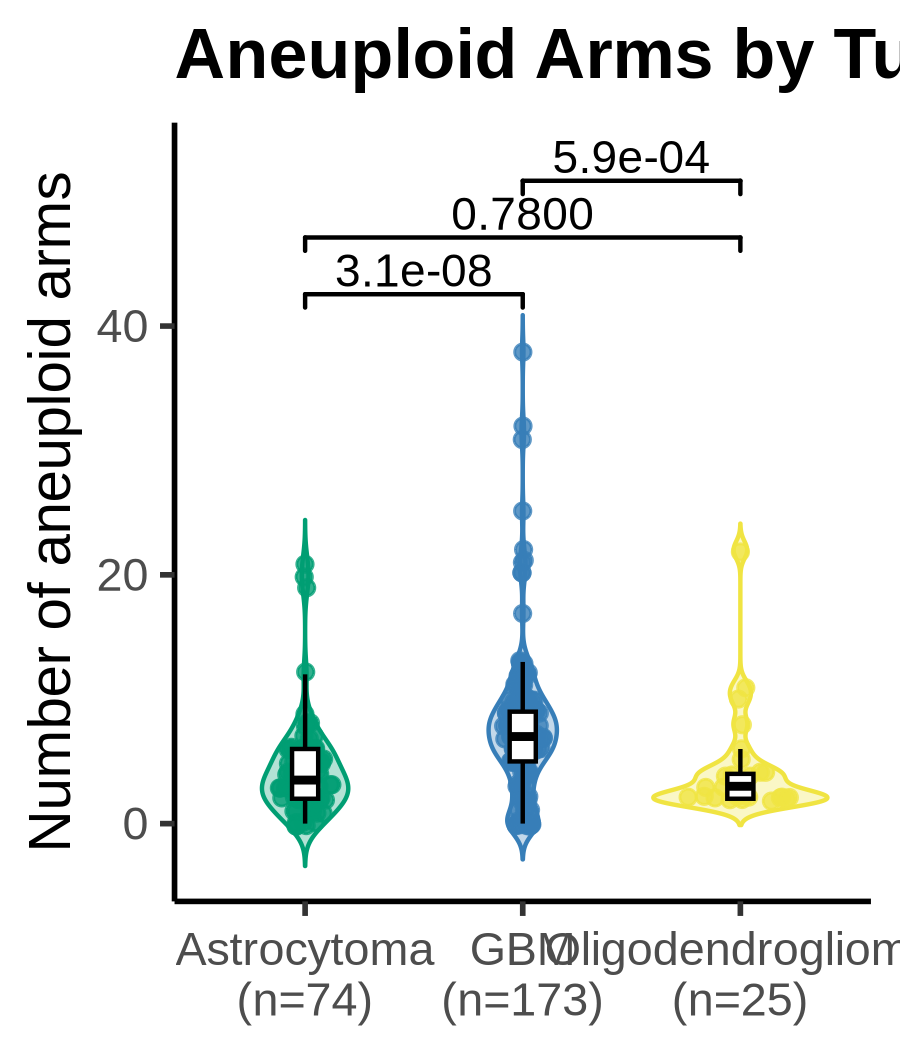

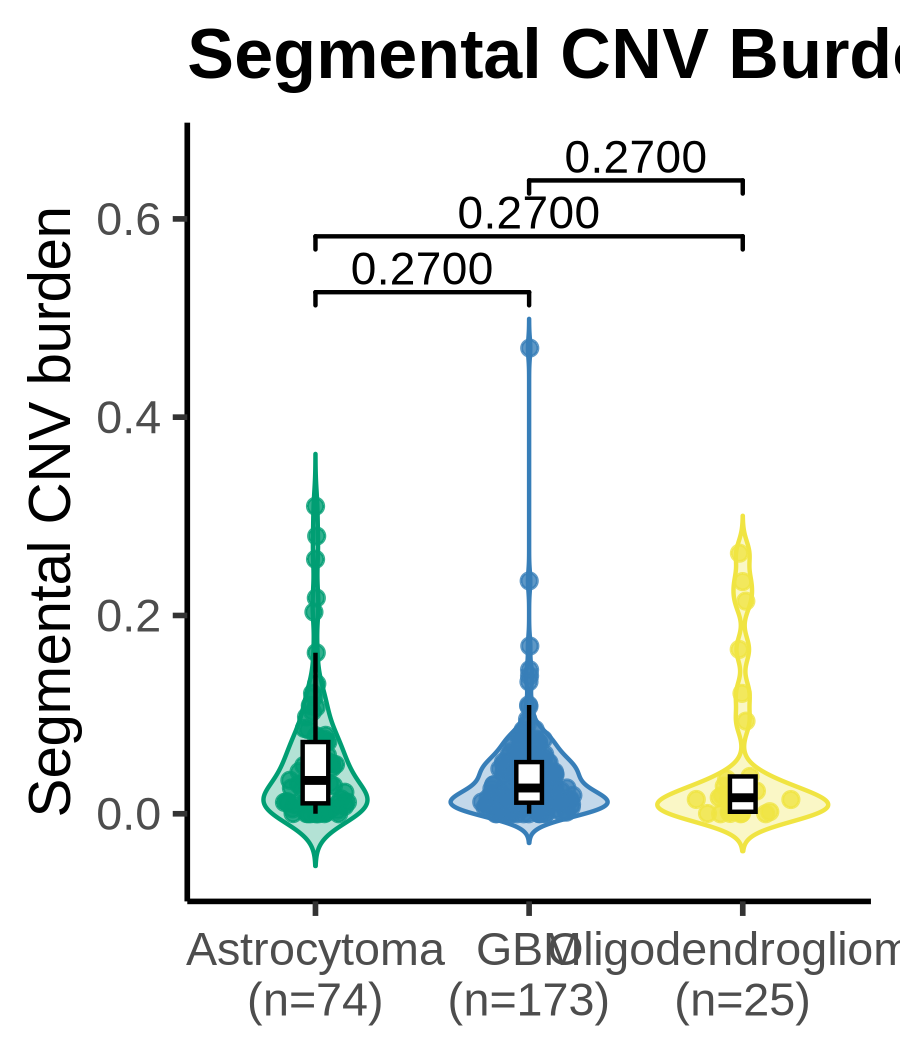

In [11]:
options(repr.plot.width = 3, repr.plot.height = 3.5, repr.plot.res = 300)

p_aneuploid
p_burden

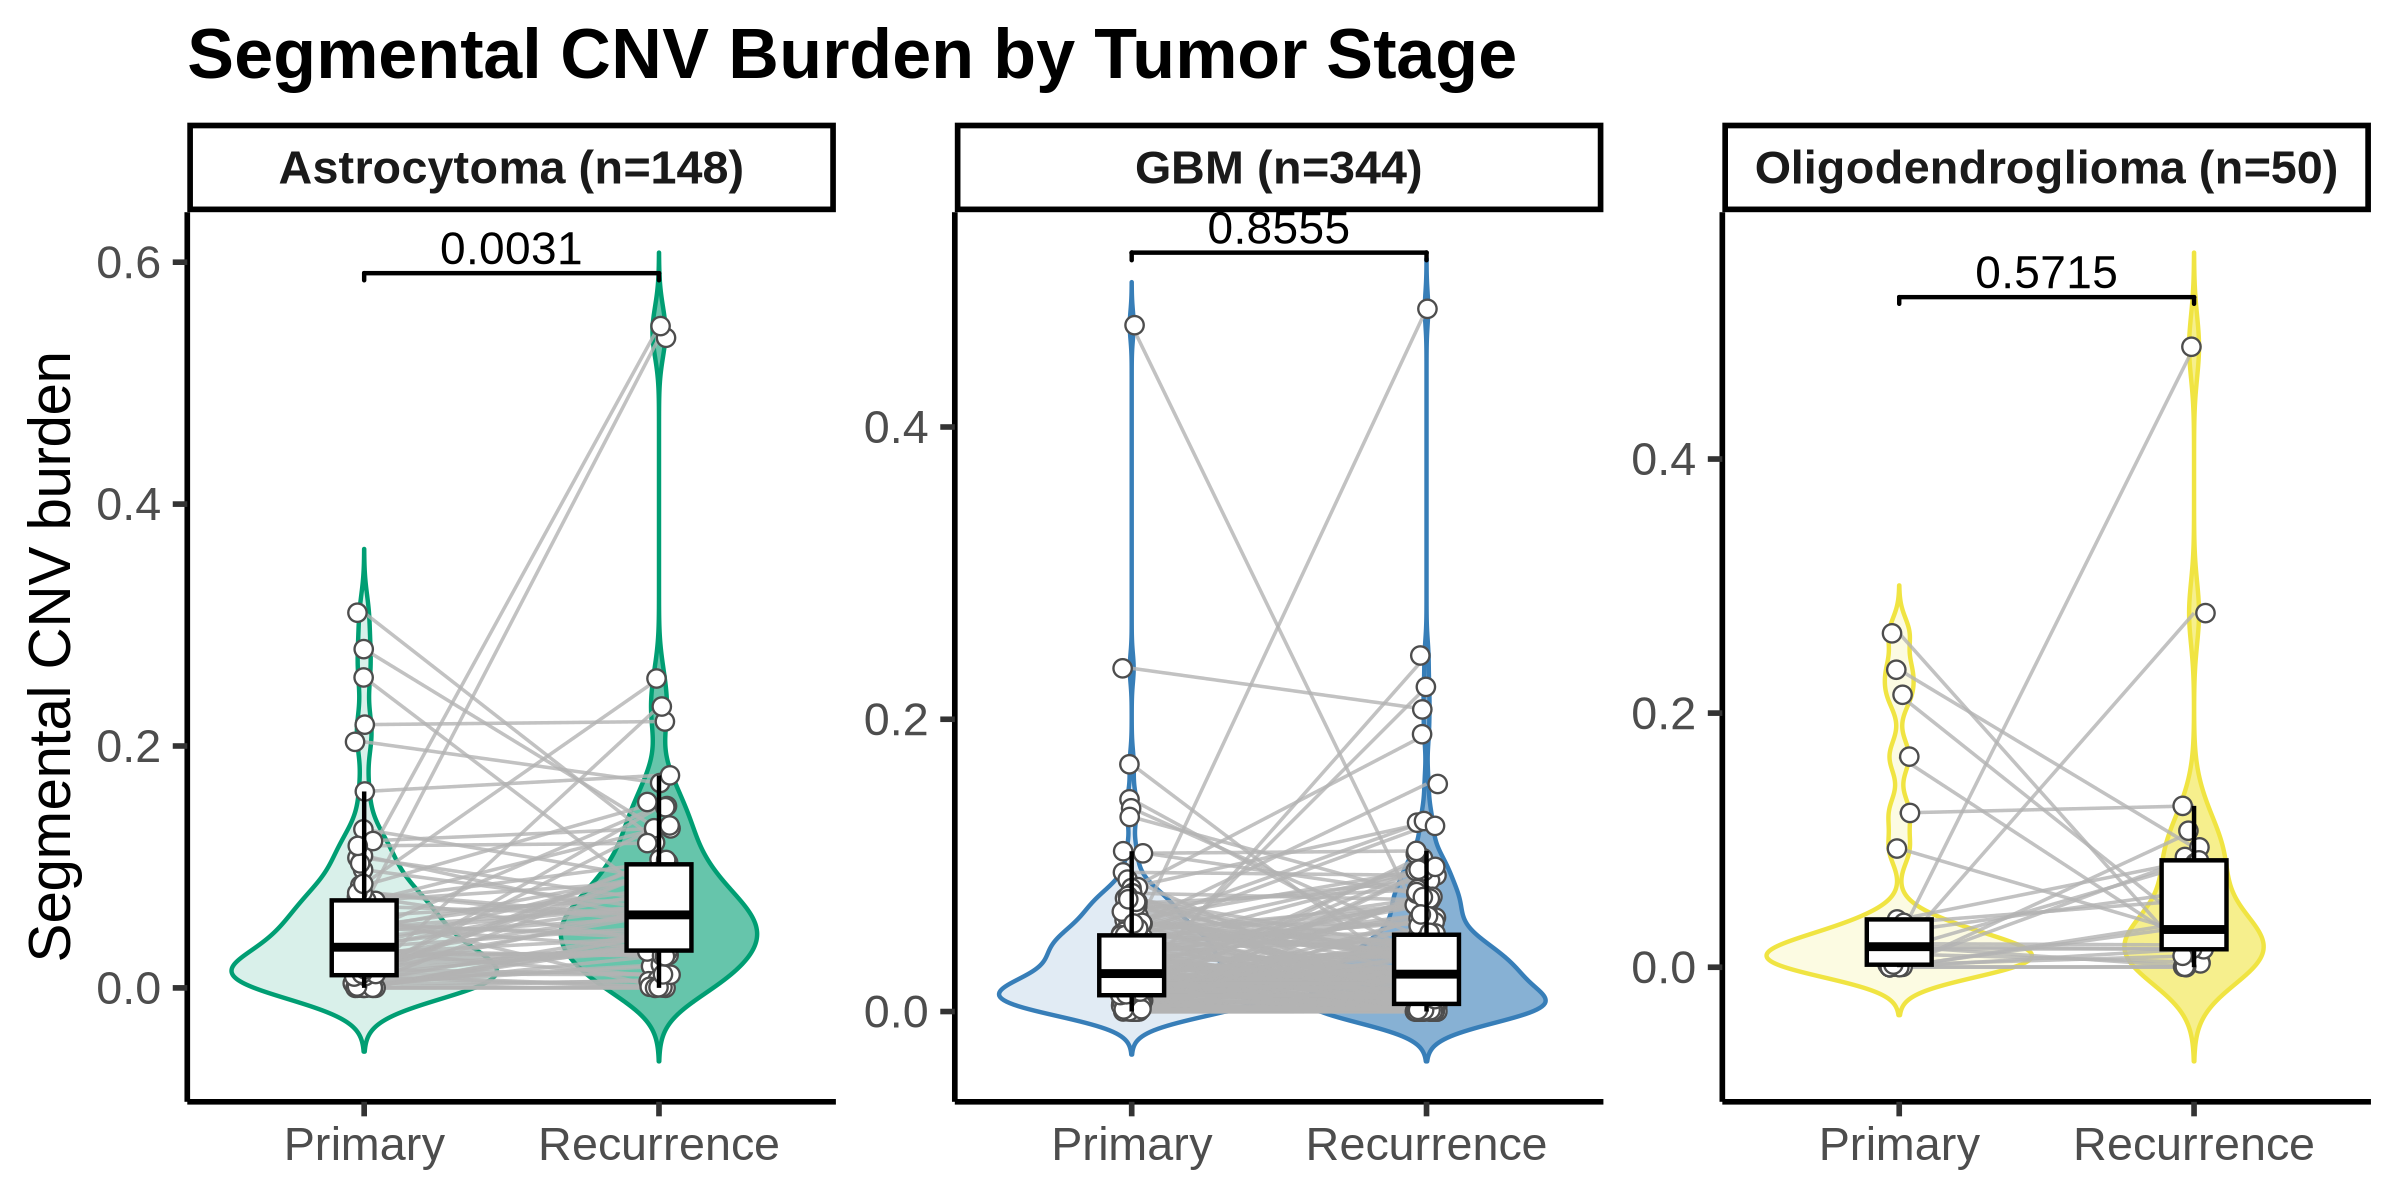

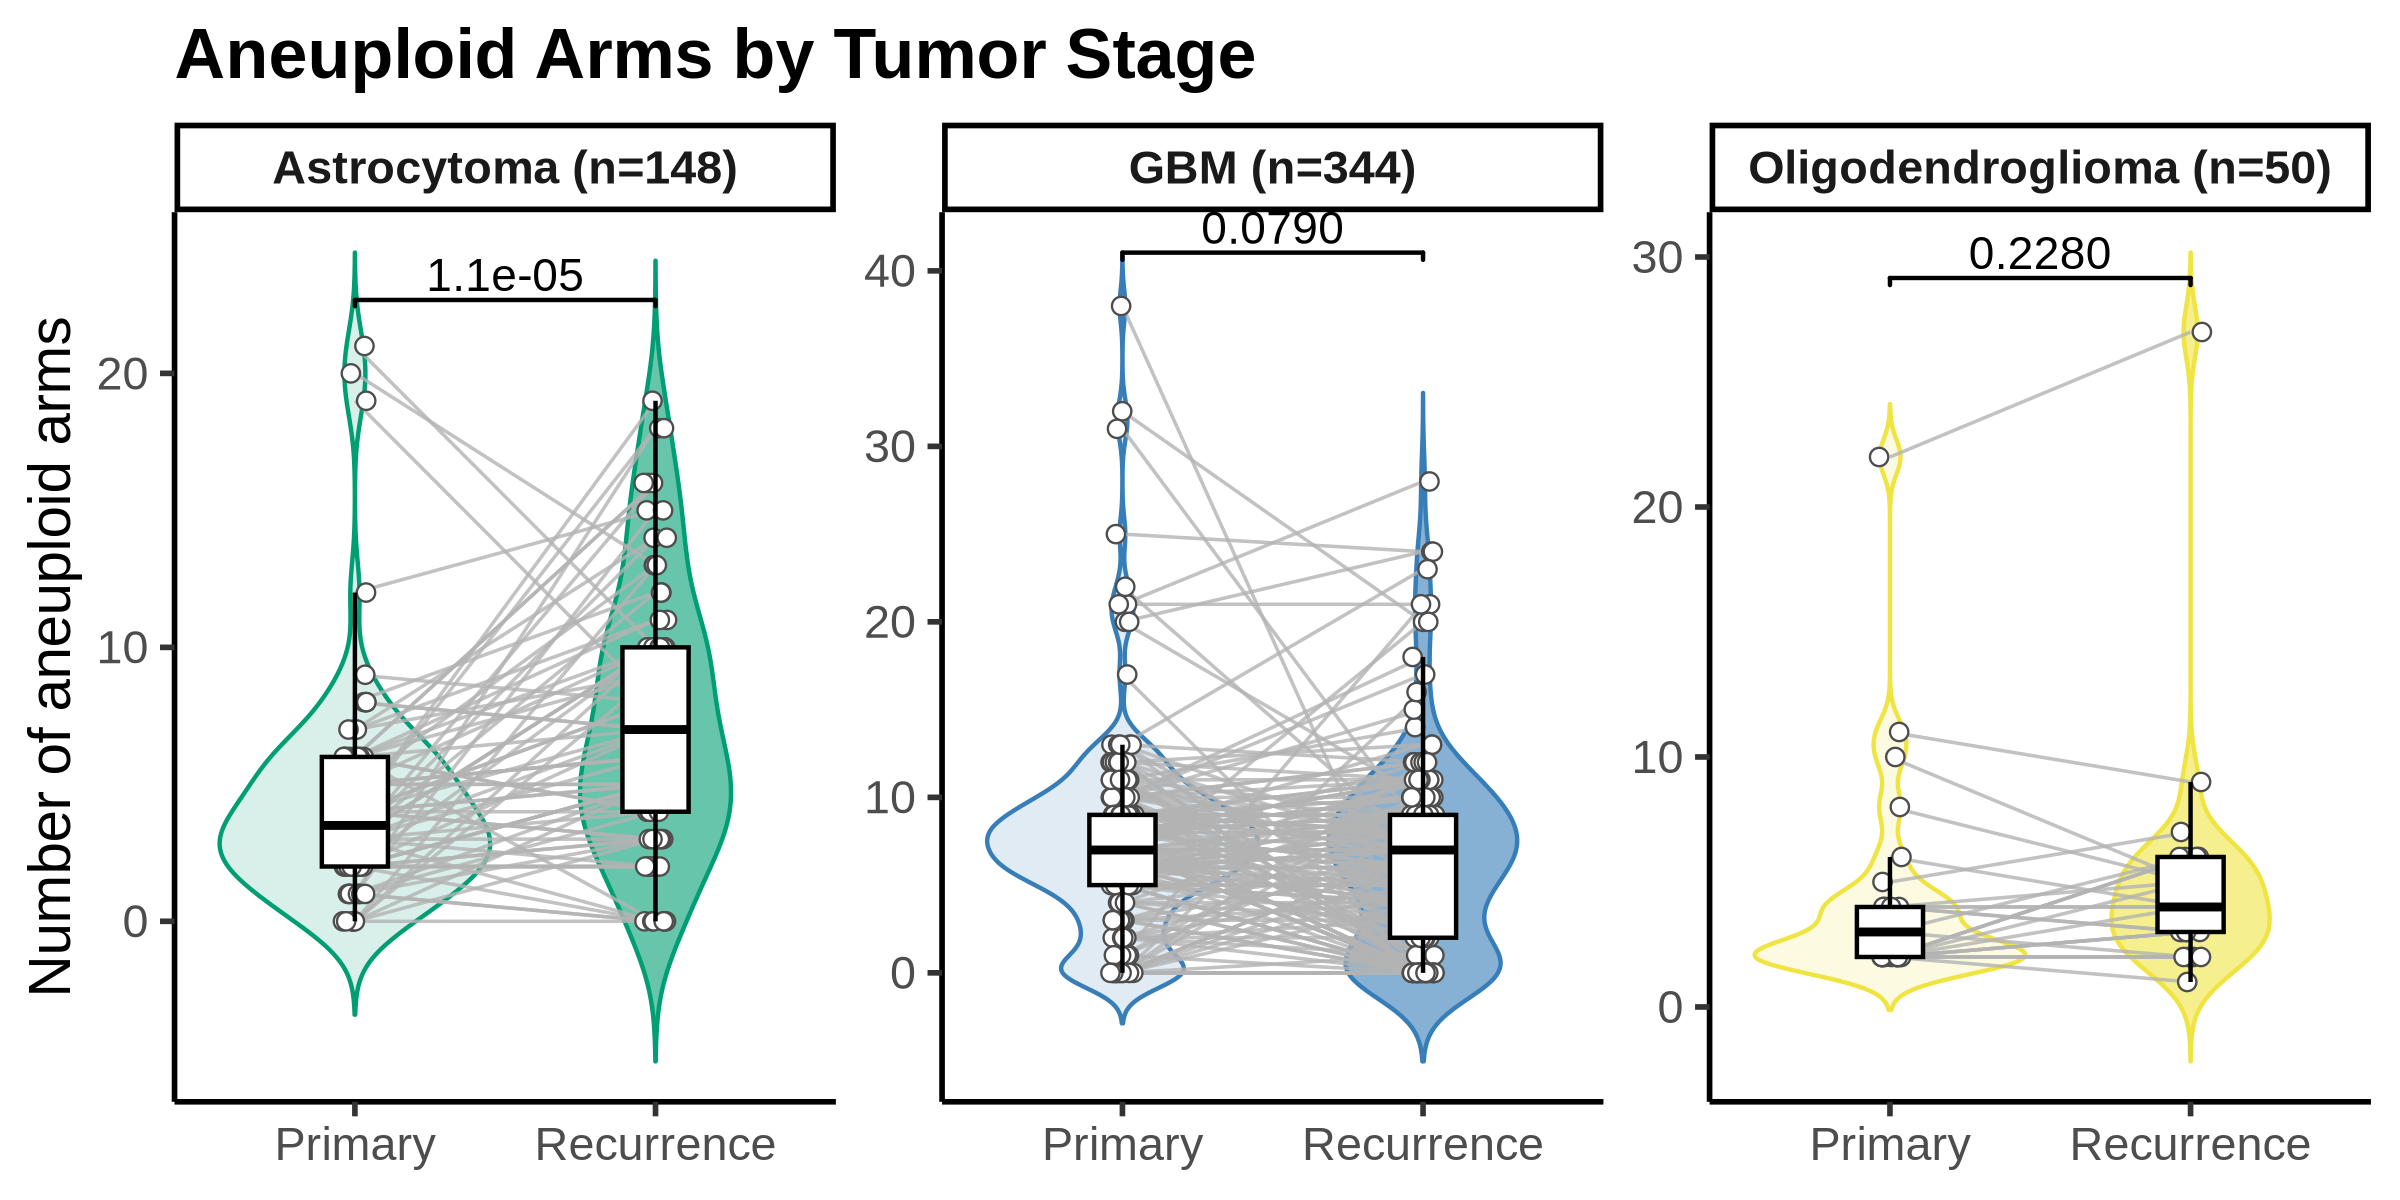

In [12]:
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 300)

p_stage_burden
p_stage_aneuploid

In [13]:
library(patchwork)

# Arrange the 8x4 plots on top and the 3x3.5 plots on bottom
combined_layout <- (p_stage_burden | p_stage_aneuploid) / 
                   (p_aneuploid | p_burden) +
                   plot_layout(heights = c(4, 3.5))

In [14]:
# Save to PDF
ggsave(
  filename = "/home/mjehangir/telomere-sv-analysis/plots/fig1/p_stage_aneuploid_paired_samples.pdf",
  plot = p_stage_aneuploid, 
  width =8, 
  height = 4, 
  device = "pdf"
)

In [15]:
# -----------------------------
# histogram function
# -----------------------------
plot_hist_by_tumor_type <- function(data, y, xlab, title, binwidth = 0.02) {
  dat <- data %>%
    filter(!is.na(tumor_type), !is.na(.data[[y]]), tumor_type %in% names(pal)) %>%
    mutate(tumor_type = factor(tumor_type, levels = names(pal)))

  counts <- dat %>% count(tumor_type, name = "n")
  facet_labs <- setNames(
    paste0(as.character(counts$tumor_type), " (n=", counts$n, ")"),
    as.character(counts$tumor_type)
  )

  medians <- dat %>%
    group_by(tumor_type) %>%
    summarise(median_val = median(.data[[y]], na.rm = TRUE), .groups = "drop")

  ggplot(dat, aes(x = .data[[y]], fill = tumor_type)) +
    geom_histogram(binwidth = binwidth, boundary = 0, alpha = 0.6, color = "black") +
    geom_vline(
      data = medians,
      aes(xintercept = median_val, color = tumor_type),
      linetype = 2,
      linewidth = 0.8,
      show.legend = FALSE,
      inherit.aes = FALSE
    ) +
    scale_fill_manual(values = pal) +
    scale_color_manual(values = pal) +
    facet_wrap(
      ~ tumor_type,
      ncol = 1,
      scales = "free_y",
      labeller = labeller(tumor_type = facet_labs)
    ) +
    labs(x = xlab, y = "Sample count", title = title) +
    theme_classic(base_size = 14) +
    theme(
      legend.position = "none",
      plot.title = element_text(face = "bold"),
      strip.text = element_text(face = "bold")
    )
}

Warning message in geom_vline(data = medians, aes(xintercept = median_val, color = tumor_type), :
“Ignoring unknown parameters: `inherit.aes`”


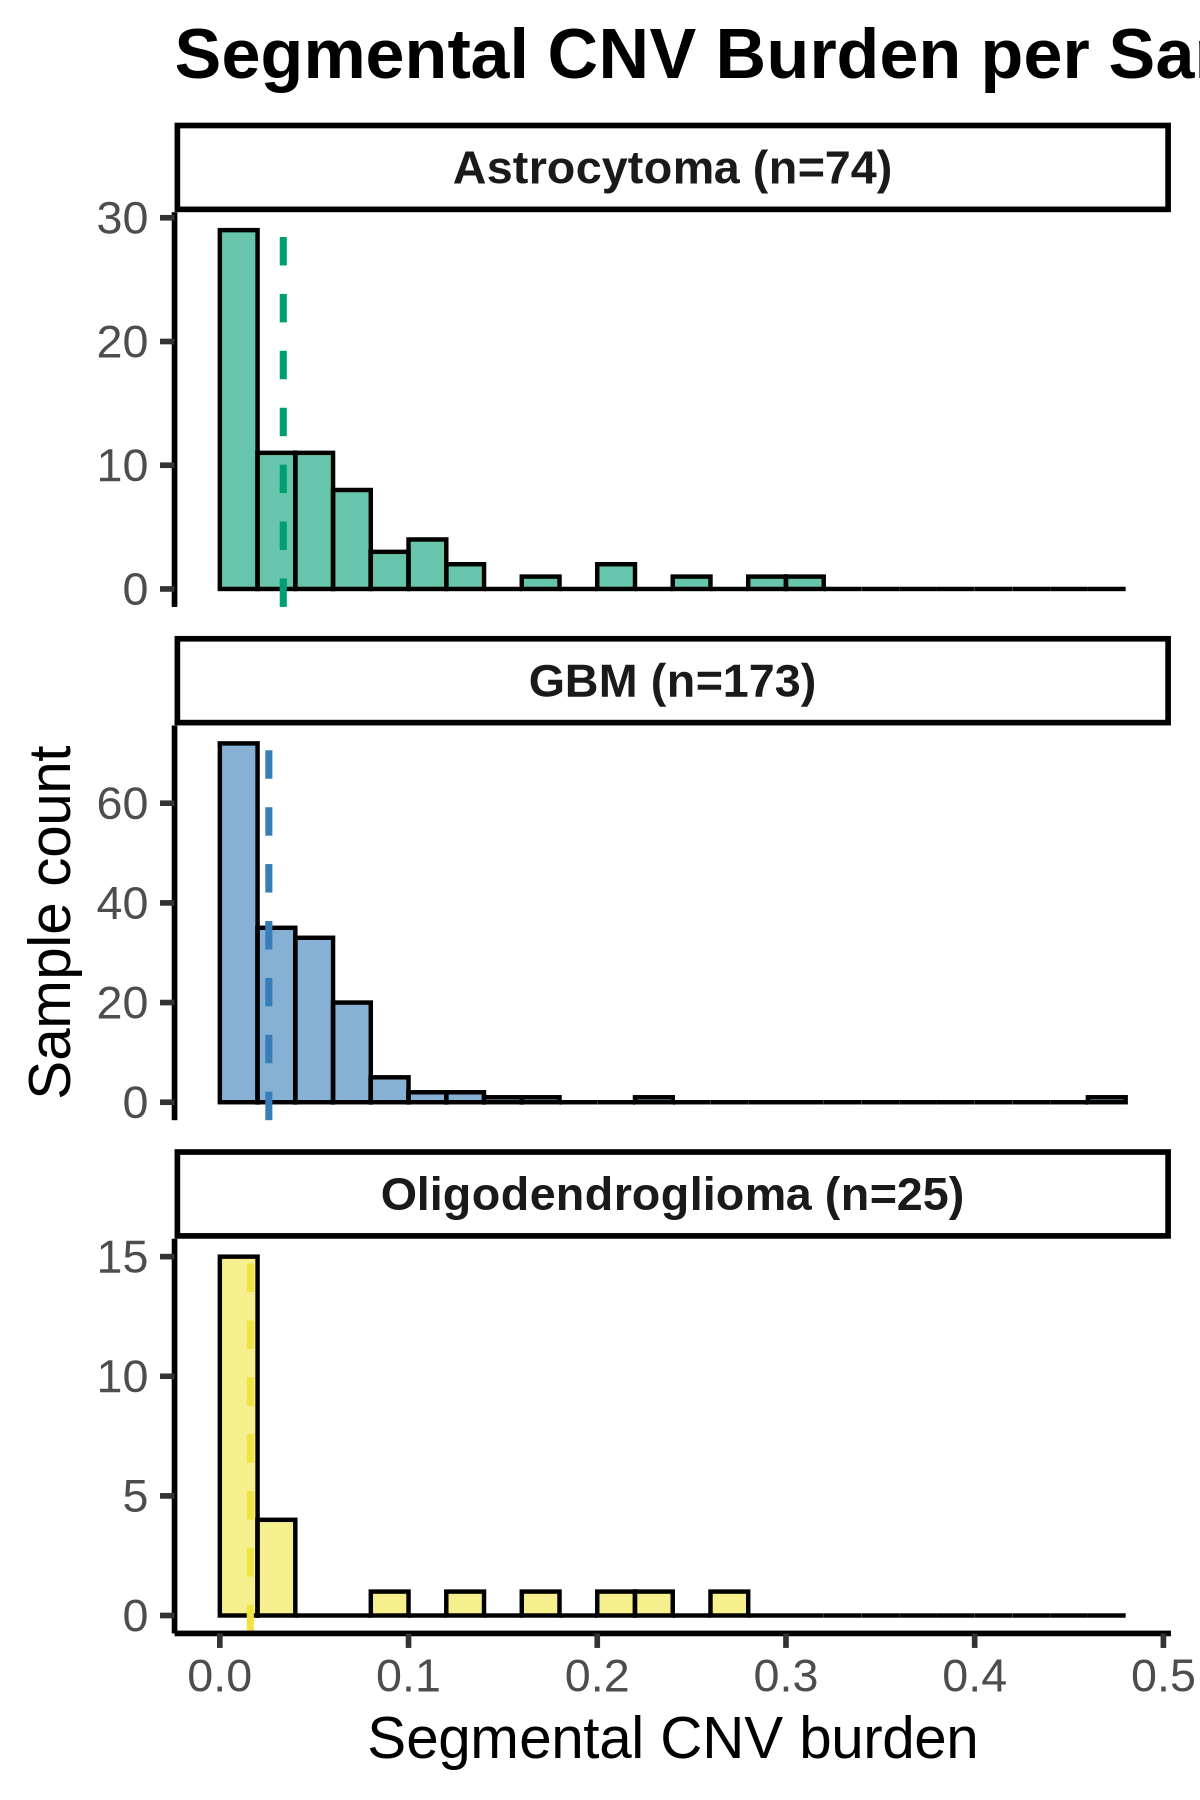

In [16]:
options(repr.plot.width = 4, repr.plot.height = 6, repr.plot.res = 300)
p_hist_burden <- plot_hist_by_tumor_type(
  sample_scores_primary,
  "segmental_cnv_burden",
  "Segmental CNV burden",
  "Segmental CNV Burden per Sample"
)
p_hist_burden